# Comprensión y Análisis Exploratorio de Datos (EDA)

  Análisis exploratorio del dataset de créditos para entender las variables, su
  calidad y su relación con la variable objetivo `Pago_atiempo` (1 = pagó a tiempo).

  Contenido:
  1. Exploración inicial (tipos, nulos, limpieza)
  2. Análisis univariable
  3. Análisis bivariable
  4. Análisis multivariable

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from Cargar_datos import cargar_datos

# que los gráficos se vean dentro del notebook con buen tamaño
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

## Carga de datos

In [2]:
df = cargar_datos()
df.head(10)

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1
5,4,2025-06-10 08:54:01,1031928.0,12,32,Empleado,2800000,800000,82872,95.227787,...,0.0,24399.0,24399.0,0.0,2,0,8,2808474.0,Creciente,1
6,4,2025-08-09 13:00:44,3064280.4,6,68,Independiente,1000000,22005000,461231,95.227787,...,0.0,211775.0,211775.0,0.0,6,3,0,969508.0,Creciente,1
7,4,2025-08-18 12:49:19,3619560.0,6,31,Empleado,3782303,305000,542079,95.227787,...,0.0,12078.0,12078.0,0.0,0,1,0,3782303.0,Creciente,1
8,9,2025-05-30 09:11:18,2134827.6,10,31,Empleado,14500000,8000000,181732,95.227787,...,0.0,0.0,NaN,NaN,0,0,0,14007850.0,Creciente,1
9,4,2024-12-31 14:32:59,8400000.0,6,45,Empleado,14000000,5000000,1166667,95.227787,...,0.0,125383.0,125383.0,0.0,2,0,0,28889623.0,Creciente,1


##  Tipos de datos y nulos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  object 
 2   capital_prestado               10763 non-null  float64
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  object 
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null 

## Estadísticas de las variables numéricas

In [4]:
df.describe()

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,5.411131,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
std,2.338279,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668
min,4.000000,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,68.000000,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000


## Estadísticas de las variables categóricas

In [5]:
df.describe(include="object")

,fecha_prestamo,tipo_laboral,tendencia_ingresos
count,10763,10763,7831
unique,10758,2,46
top,2025-04-10 18:14:34,Empleado,Creciente
freq,2,6754,5294


## Nulos por columna

In [6]:
#Cantidad y porcentaje de valores nulos por columna
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100
tabla_nulos = pd.DataFrame({'nulos': nulos, '%': porcentaje})
tabla_nulos[tabla_nulos["nulos"] > 0].sort_values("nulos", ascending=False)

,nulos,%
tendencia_ingresos,2932,27.241475
promedio_ingresos_datacredito,2930,27.222893
saldo_mora_codeudor,590,5.481743
saldo_principal,405,3.762891
saldo_mora,156,1.449410
saldo_total,156,1.449410
puntaje_datacredito,6,0.055747


### Observaciones sobre nulos
  - `tendencia_ingresos` y `promedio_ingresos_datacredito` tienen ~27% de valores
    faltantes: es un volumen alto que habrá que tratar (imputar o evaluar si se
    descartan) en la etapa de ingeniería de características.
  - Las variables de saldo tienen pocos nulos (1-5%), más fáciles de imputar.
  - `puntaje_datacredito` casi no tiene nulos.

## Convertir la fecha

In [7]:
# Convertir fecha_prestamo de texto a fecha
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"])

# Verificar que cambió el tipo
df["fecha_prestamo"].dtype


dtype('<M8[ns]')

## Limpieza de tendencia_ingresos

In [8]:
validas = ["Creciente", "Decreciente", "Estable"]
df["tendencia_ingresos"] = df["tendencia_ingresos"].where( 
    df["tendencia_ingresos"].isin(validas), np.nan
)
print(df["tendencia_ingresos"].value_counts(dropna=False)) 

tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64


## 2. Análisis univariable

## Agrupar columnas por tipo

In [9]:
# Variables numéricas (cantidades reales)
numericas = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
    "saldo_principal", "saldo_mora_codeudor", "creditos_sectorFinanciero",
    "creditos_sectorCooperativo", "creditos_sectorReal", "promedio_ingresos_datacredito",
]

# Variables categóricas (incluye las que son números pero representan categorías)
categoricas = ["tipo_credito", "tipo_laboral", "tendencia_ingresos", "Pago_atiempo"]

print("Numéricas:", len(numericas))
print("Categóricas:", len(categoricas))

Numéricas: 18
Categóricas: 4


### Histogramas (distribución de las variables numéricas)

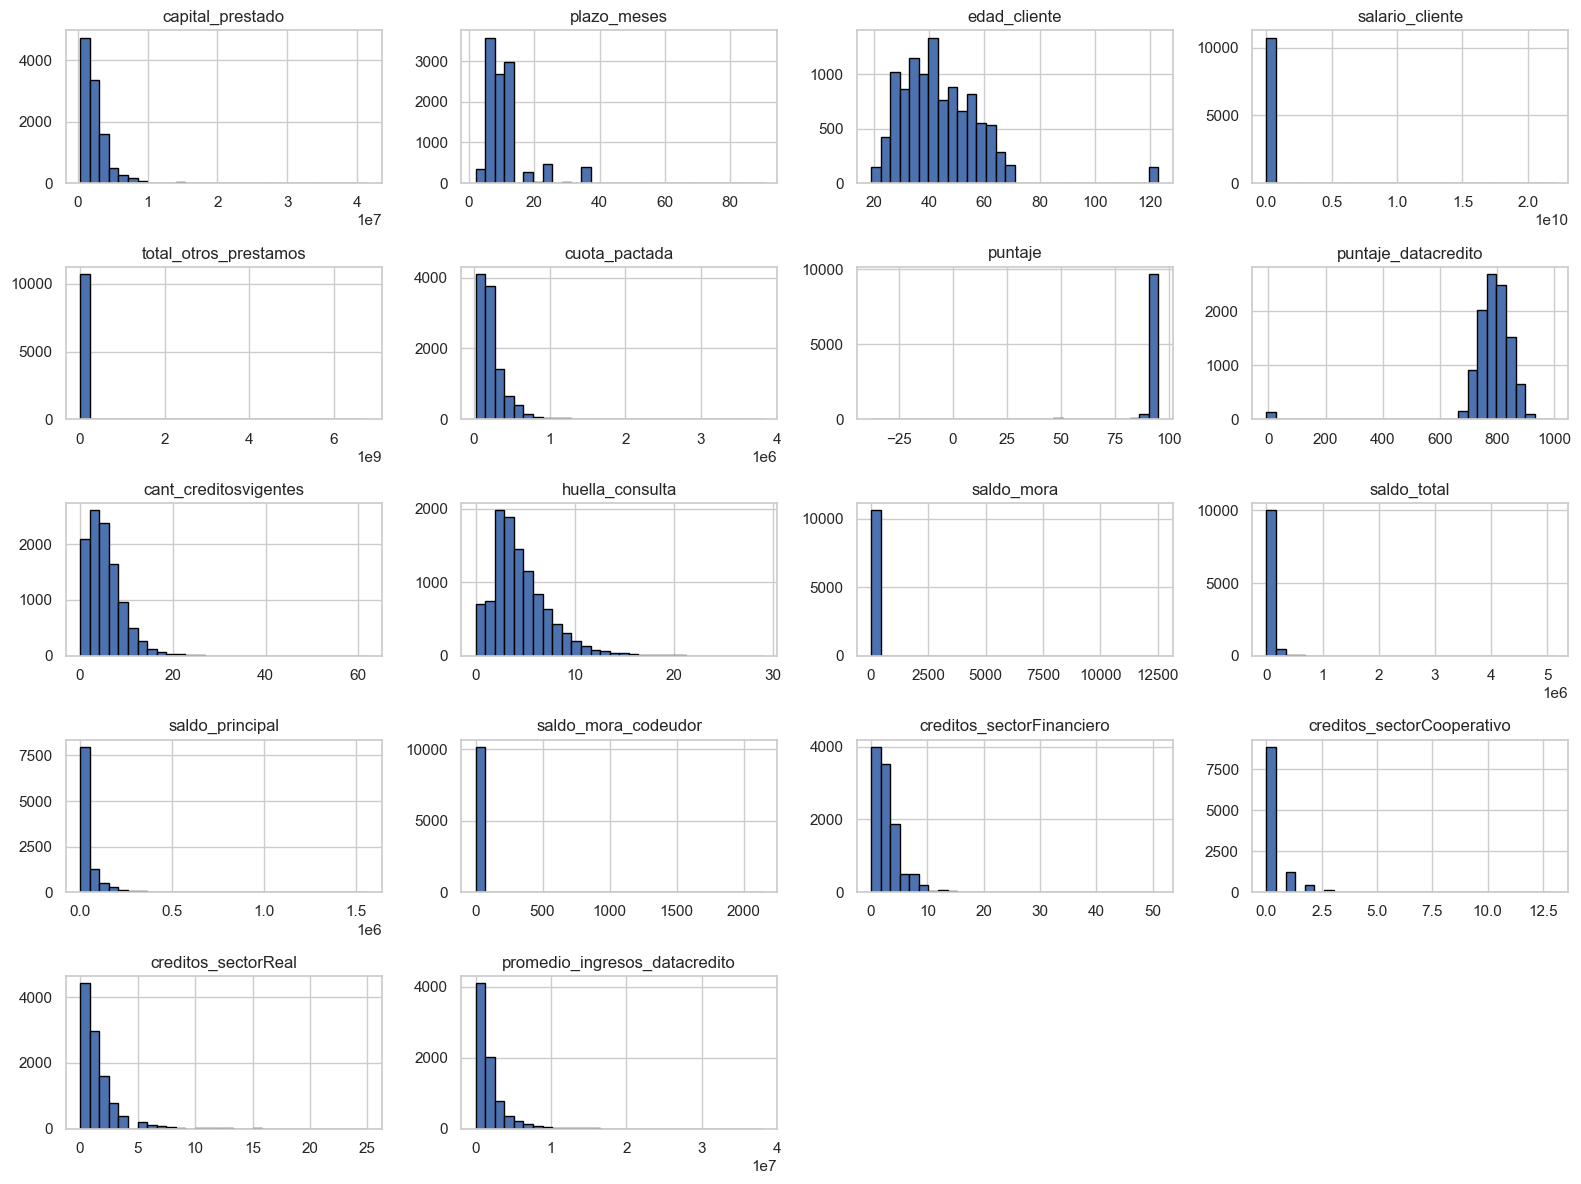

In [10]:
df[numericas].hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

### Asimetría y curtosis

In [11]:
# Asimetría (skewness) y curtosis de las variables numéricas
forma = pd.DataFrame({
    "skewness": df[numericas].skew(),
    "kurtosis": df[numericas].kurt(),
}).round(2).sort_values("skewness", ascending=False)
forma

,skewness,kurtosis
saldo_mora_codeudor,94.97,9279.82
salario_cliente,43.78,2211.23
saldo_mora,40.57,1845.71
total_otros_prestamos,38.46,1719.28
saldo_total,20.20,789.17
saldo_principal,5.05,51.06
promedio_ingresos_datacredito,4.28,32.77
creditos_sectorCooperativo,4.22,29.35
cuota_pactada,3.79,26.65
capital_prestado,3.72,35.32


### Interpretación de asimetría (skewness) y curtosis

- **Sesgo positivo fuerte (cola a la derecha):** casi todas las variables monetarias
y de conteo. Casos extremos: `saldo_mora_codeudor` (95) y `saldo_mora` (41) están
casi todas en 0 (la mayoría no registra mora); `salario_cliente` (44),
`total_otros_prestamos` (38) y `saldo_total` (20) tienen pocos valores muy altos.
- **Sesgo negativo (cola a la izquierda):** `puntaje` (-4.9) y `puntaje_datacredito`
(-5.6): la mayoría de los clientes tiene puntaje alto.
- **Curtosis muy alta** en casi todas: indica gran cantidad de outliers, que habrá que
tratar en la ingeniería de características.
- **Implicancia:** las variables muy sesgadas son candidatas a transformación
(ej: logaritmo) para acercarlas a una forma más simétrica.

### Boxplots (detección de outliers)

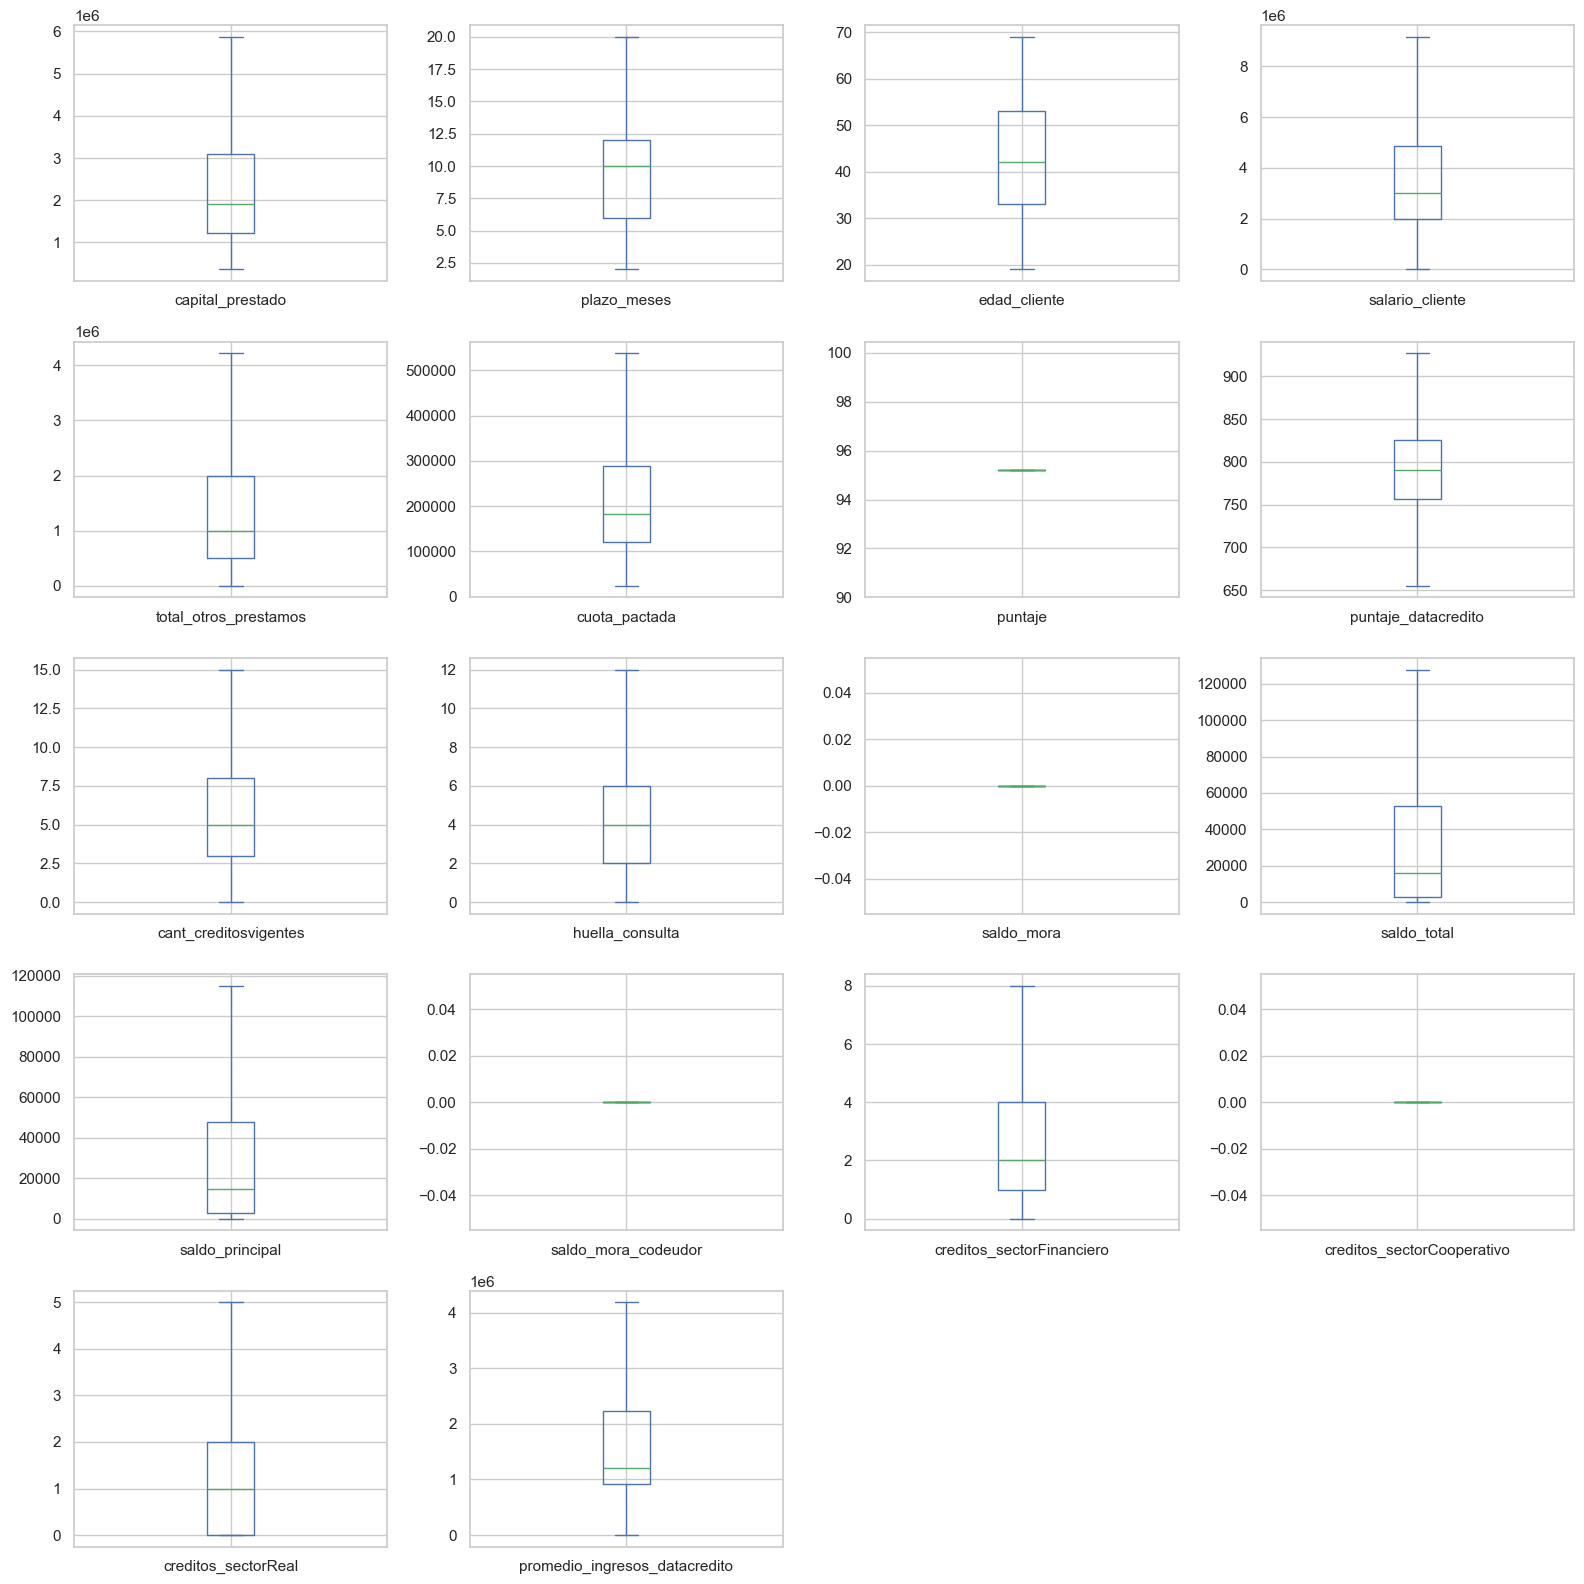

In [12]:
df[numericas].plot(kind="box", subplots=True, layout=(5, 4),
                    figsize=(16, 16), sharex=False, sharey=False,
                    showfliers=False)
plt.tight_layout()
plt.show()

## 3. Análisis bivariable

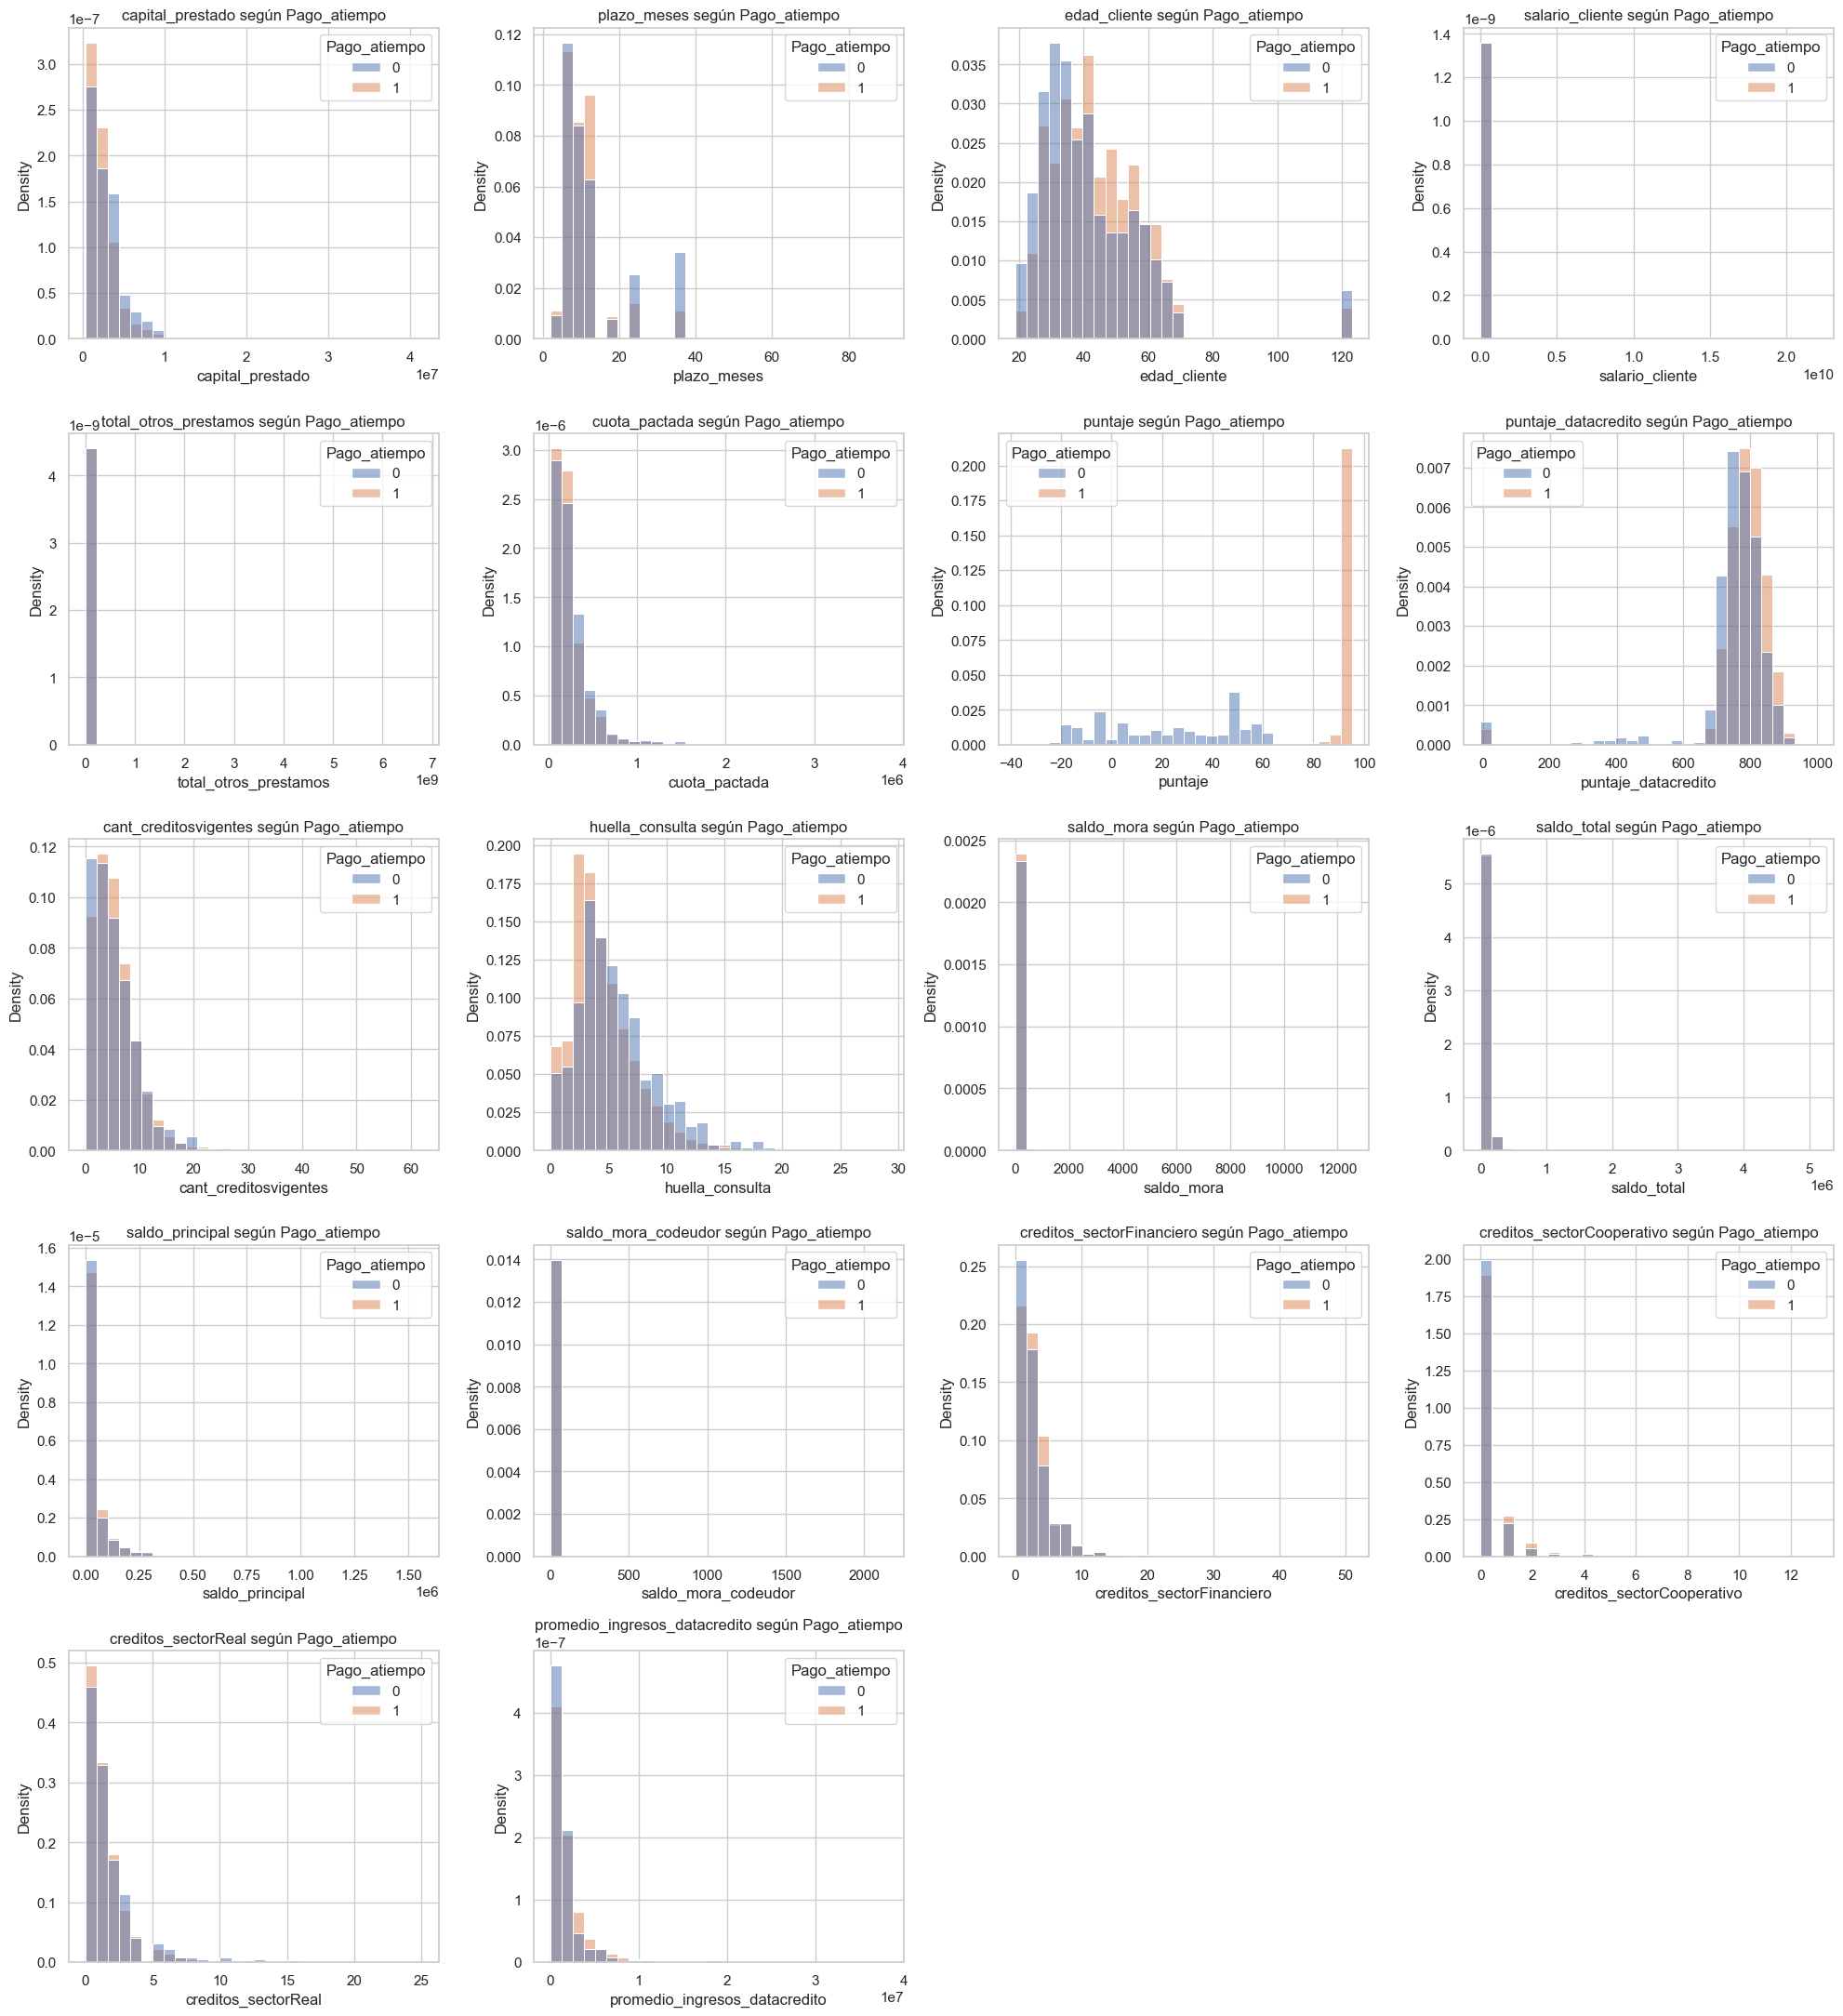

In [13]:
fig, axes = plt.subplots(5, 4, figsize=(20, 22))
axes = axes.flatten()   # convertir la grilla en una lista para recorrerla

for i, col in enumerate(numericas):
    sns.histplot(data=df, x=col, hue="Pago_atiempo",
                stat="density", common_norm=False, bins=30, ax=axes[i])
    axes[i].set_title(f"{col} según Pago_atiempo")

# apagar las casillas que sobran (18 variables, 20 casillas)
for j in range(len(numericas), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

 ### Variables destacadas (gráficos individuales)
Análisis en detalle de los predictores más relevantes según el objetivo.

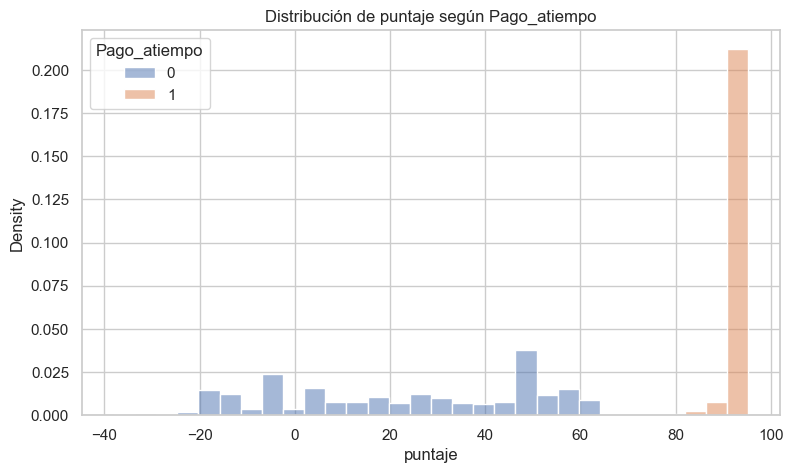

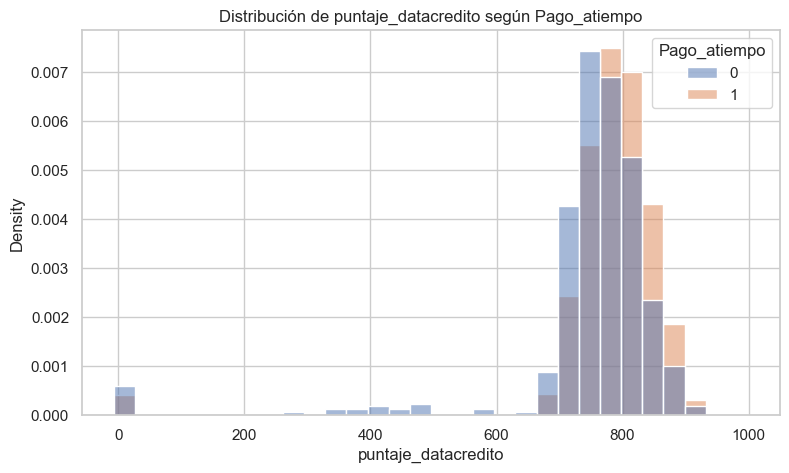

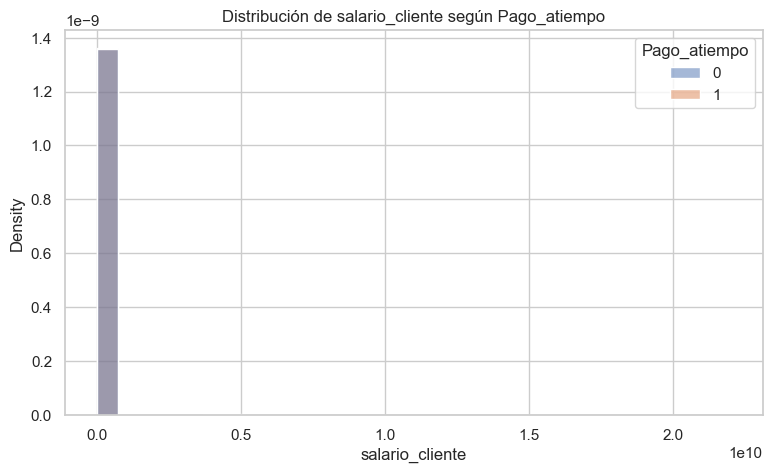

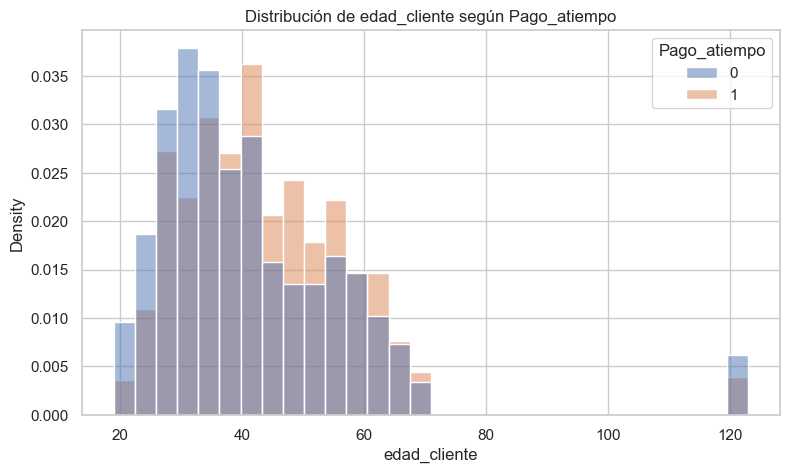

In [14]:
destacadas = ["puntaje", "puntaje_datacredito", "salario_cliente", "edad_cliente"]

for col in destacadas:
    plt.figure(figsize=(9, 5))
    sns.histplot(data=df, x=col, hue="Pago_atiempo",
                stat="density", common_norm=False, bins=30)
    plt.title(f"Distribución de {col} según Pago_atiempo")
    plt.show()

 ## 4. Análisis multivariable

### Matriz de correlación

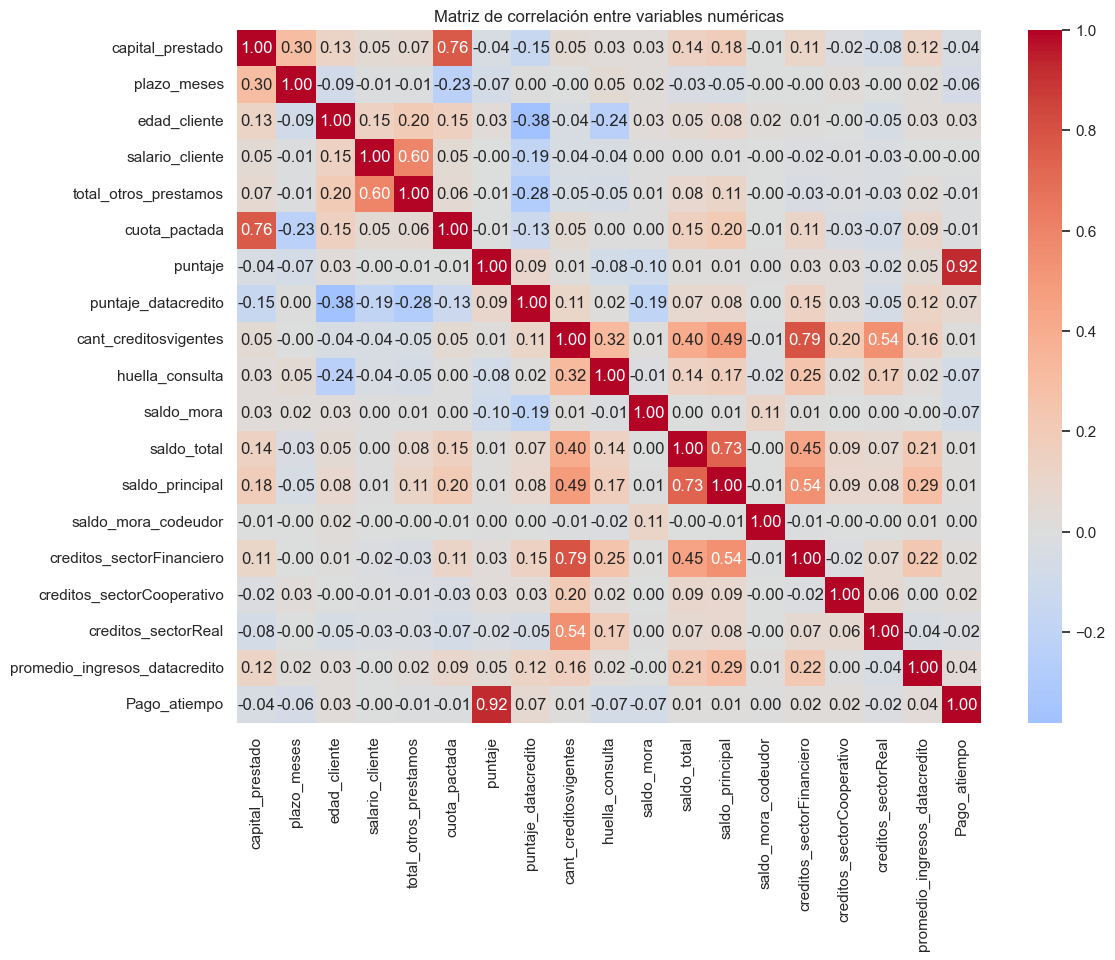

In [15]:
plt.figure(figsize=(12, 9))
corr = df[numericas + ["Pago_atiempo"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

### Observaciones de la matriz de correlación
- `puntaje` es, por lejos, la variable más correlacionada con `Pago_atiempo` (0.92).
Será el predictor dominante del modelo.
- El resto de las variables numéricas tiene correlación lineal muy baja (<0.08),
incluido `puntaje_datacredito` (0.07).
- La correlación de 0.92 de `puntaje` es muy alta: conviene verificar que sea una
variable disponible antes de otorgar el crédito (y no un posible leakage).
- La baja correlación lineal no descarta relaciones no lineales (ver análisis bivariable).

---

### Cruces de variables categóricas con el objetivo

In [16]:
categoricas_texto = ["tipo_laboral", "tendencia_ingresos"]

for col in categoricas_texto:
    print(f"=== {col} vs Pago_atiempo (% por categoría) ===")
    tabla = pd.crosstab(df[col], df["Pago_atiempo"], normalize="index").round(3) * 100
    print(tabla)
    print()

=== tipo_laboral vs Pago_atiempo (% por categoría) ===
Pago_atiempo     0     1
tipo_laboral            
Empleado       4.3  95.7
Independiente  5.5  94.5

=== tendencia_ingresos vs Pago_atiempo (% por categoría) ===
Pago_atiempo          0     1
tendencia_ingresos           
Creciente           3.9  96.1
Decreciente         6.3  93.7
Estable             4.6  95.4

